# Q2 方向A：Agent 驱动的自动化特征工程系统

**目标**：Agent 系统从 300 个金融特征中自动筛选最优 50 个，对 Y7 进行分类预测。

---

## 结果索引

| 关键输出 | Cell |
|---------|------|
| 数据概况可视化 | Cell 3 |
| Phase 1 诊断报告 | Cell 6–7 |
| Phase 2 清理验证 | Cell 9–10 |
| Phase 3 特征评估（IC/AUC）| Cell 12–14 |
| Phase 4 Top 50 筛选 | Cell 16–17 |
| 评估指标 AUC/Precision/Recall/F1 | Cell 19 |
| ROC 曲线 / 混淆矩阵 | Cell 20 |
| 数据泄漏检测 | Cell 22 |


In [1]:
import sys, os
sys.path.insert(0, 'code')
os.makedirs('outputs', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang HK', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

import lightgbm as lgb
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve)
from tqdm import tqdm
import time

from agent import FeatureAgent
from metrics import batch_cs_ic, ic_ir, feature_auc, group_monotonicity
from prompts import DIAGNOSE, CLEAN, EVALUATE, SELECT

print("✓ 环境初始化完成")


✓ 环境初始化完成


In [2]:
df = pd.read_parquet('../data.pq')
x_cols = sorted([c for c in df.columns if c.startswith('X')], key=lambda c: int(c[1:]))
TARGET = 'Y7'

# 时间切分 70/30，严格按日期顺序
dates      = sorted(df['trade_date'].unique())
split_idx  = int(len(dates) * 0.7)
split_date = dates[split_idx]
train_dates = set(dates[:split_idx])
test_dates  = set(dates[split_idx:])

print(f"数据维度   : {df.shape}")
print(f"交易日范围 : {str(dates[0])[:10]} ~ {str(dates[-1])[:10]}  ({len(dates)} 天)")
print(f"标的数量   : {df['underlying'].nunique()}")
print(f"训练集     : {str(dates[0])[:10]} ~ {str(dates[split_idx-1])[:10]}  ({len(train_dates)} 天)")
print(f"测试集     : {str(dates[split_idx])[:10]} ~ {str(dates[-1])[:10]}  ({len(test_dates)} 天)")
print(f"\n{TARGET} 标签分布（训练+测试）:")
vc = df[TARGET].value_counts(normalize=True).sort_index()
for v, p in vc.items():
    print(f"  {int(v):+d} : {p*100:.1f}%")

# 共享状态字典（Agent 通过 state 读写数据）
state = dict(
    df=df, x_cols=x_cols, target=TARGET,
    train_dates=train_dates, test_dates=test_dates, split_date=split_date,
)


数据维度   : (81046, 321)
交易日范围 : 2015-01-05 ~ 2020-12-31  (1462 天)
标的数量   : 70
训练集     : 2015-01-05 ~ 2019-03-15  (1023 天)
测试集     : 2019-03-18 ~ 2020-12-31  (439 天)

Y7 标签分布（训练+测试）:
  -1 : 34.1%
  +0 : 32.0%
  +1 : 33.9%


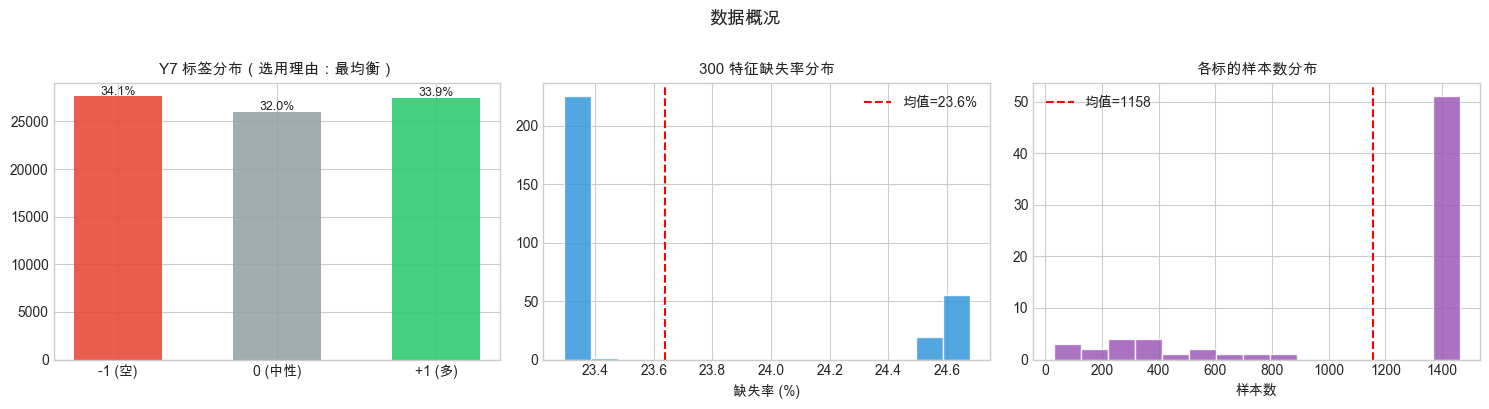

面板数据: 70 标的 × 1462 交易日，实际行数 81046


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Y7 分布
vc = df[TARGET].value_counts().sort_index()
bars = axes[0].bar(['-1 (空)', '0 (中性)', '+1 (多)'], vc.values,
                   color=['#e74c3c', '#95a5a6', '#2ecc71'], width=0.55, alpha=0.9)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val/len(df)*100:.1f}%', ha='center', fontsize=9)
axes[0].set_title(f'{TARGET} 标签分布（选用理由：最均衡）', fontsize=11)

# 特征缺失率分布
null_pcts = df[x_cols].isnull().mean() * 100
axes[1].hist(null_pcts, bins=15, color='#3498db', alpha=0.85, edgecolor='white')
axes[1].axvline(null_pcts.mean(), color='red', ls='--', lw=1.5,
                label=f'均值={null_pcts.mean():.1f}%')
axes[1].set_title('300 特征缺失率分布', fontsize=11)
axes[1].set_xlabel('缺失率 (%)')
axes[1].legend()

# 各标的样本数
uc = df.groupby('underlying').size()
axes[2].hist(uc.values, bins=15, color='#9b59b6', alpha=0.85, edgecolor='white')
axes[2].axvline(uc.mean(), color='red', ls='--', lw=1.5, label=f'均值={uc.mean():.0f}')
axes[2].set_title('各标的样本数分布', fontsize=11)
axes[2].set_xlabel('样本数')
axes[2].legend()

plt.suptitle('数据概况', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"面板数据: {df['underlying'].nunique()} 标的 × {len(dates)} 交易日，实际行数 {len(df)}")


In [4]:
from agent import DEEPSEEK_BASE_URL, MODEL

agent = FeatureAgent(state, verbose=True)
print(f"✓ FeatureAgent 初始化完成")
print(f"  模型 : {MODEL}")
print(f"  代理 : {DEEPSEEK_BASE_URL}")


✓ FeatureAgent 初始化完成
  模型 : deepseek/deepseek-chat
  代理 : https://openrouter.fans/v1


## Phase 1：自动特征诊断

Agent 遍历 X1~X300，生成并执行诊断代码：
- 计算每个特征的缺失率、零值比例、均值/std/skew/kurt、IQR 法异常值比例
- 识别缺失模式（缺失行完全相同的特征归为同一 null_group）
- 输出结构化诊断报告 `state['diagnose_report']`


In [5]:
agent.reset()
print("=" * 60)
print("Phase 1: 自动特征诊断")
print("=" * 60)
_ = agent.run(DIAGNOSE)

# 容错：若 Agent 未写入 diagnose_report，手动生成
if 'diagnose_report' not in state:
    print("\n[fallback] 手动生成诊断报告")
    rows = []
    for x in state['x_cols']:
        col = state['df'][x].dropna()
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        rows.append({
            'feature':     x,
            'null_pct':    state['df'][x].isnull().mean() * 100,
            'zero_pct':    (state['df'][x] == 0).mean() * 100,
            'mean':        col.mean(),
            'std':         col.std(),
            'skew':        col.skew(),
            'kurt':        col.kurtosis(),
            'outlier_pct': ((col < q1 - 1.5*iqr) | (col > q3 + 1.5*iqr)).mean() * 100,
            'null_group':  state['df'][x].isnull().sum(),
        })
    state['diagnose_report'] = pd.DataFrame(rows)
    print(f"诊断报告生成完成，共 {len(state['diagnose_report'])} 条")


Phase 1: 自动特征诊断

[Step 1] 生成代码:
---------------------------------------------
import pandas as pd
import numpy as np
from scipy import stats

# 检查数据
df = state['df']
x_cols = state['x_cols']
target = state['target']

print(f"数据形状: {df.shape}")
print(f"特征数量: {len(x_cols)}")
print(f"目标变量: {target}")
print(f"特征示例: {x_cols[:10]}")
print(f"数据列: {df.columns.tolist()[:10]}...")
---------------------------------------------
[输出] 数据形状: (81046, 321)
特征数量: 300
目标变量: Y7
特征示例: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
数据列: ['trade_date', 'underlying', 'start_time', 'end_time', 'open', 'high', 'low', 'close', 'volume', 'Y1']...

[决策] 特征诊断 | 开始全面特征诊断分析 — 对300个X特征进行全面的统计诊断，包括缺失值分析、分布特征和异常值检测

[Step 3] 生成代码:
---------------------------------------------
# 提取特征数据
features_df = df[x_cols].copy()
print(f"特征数据形状: {features_df.shape}")

# 初始化结果存储
results = []

# 计算每个特征的统计量
for col in x_cols:
    col_data = features_df[col].astype(float)
    
    # 基本统计
    null_pct = col_data.isnull().me

诊断报告维度: (300, 10)
  feature   null_pct  zero_pct      mean       std       skew         kurt  outlier_pct     dist_type    null_group
0      X1  23.344767       0.0  1.000378  0.020515  65.347358  4836.633226     8.408718  heavy_tailed  null_group_0
1      X2  23.344767       0.0  1.000374  0.005190  16.615177   313.203365     5.298909  heavy_tailed  null_group_0
2      X3  23.344767       0.0 -0.038363  0.085565  -2.943846     9.042063    12.593761        skewed  null_group_0


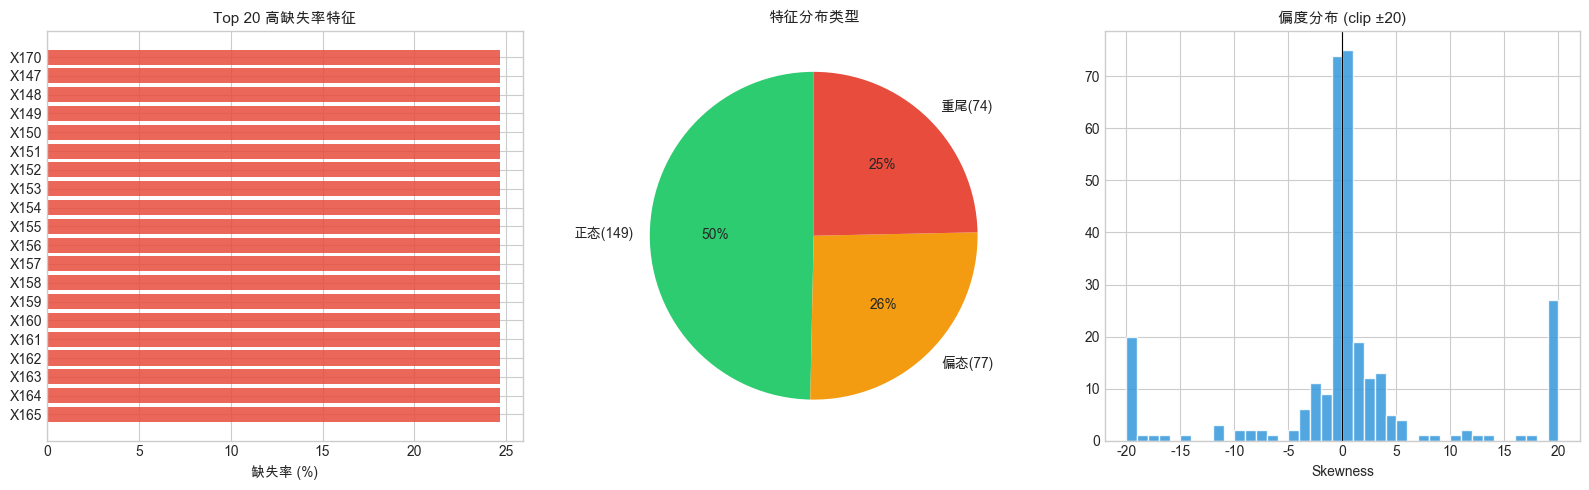


null_group 统计 (不同缺失行数):
null_group
null_group_0     86
null_group_1      1
null_group_2    139
null_group_3     19
null_group_4     54
null_group_5      1


In [6]:
raw_diag = state['diagnose_report']
if isinstance(raw_diag, pd.DataFrame):
    diag = raw_diag.copy()
elif isinstance(raw_diag, dict):
    if isinstance(raw_diag.get('rows'), list):
        diag = pd.DataFrame(raw_diag['rows'])
    elif isinstance(raw_diag.get('data'), list):
        diag = pd.DataFrame(raw_diag['data'])
    else:
        diag = pd.DataFrame(raw_diag)
else:
    diag = pd.DataFrame(raw_diag)

if 'feature' not in diag.columns:
    diag = diag.reset_index().rename(columns={'index': 'feature'})
if 'feature' not in diag.columns:
    diag['feature'] = [f'X{i+1}' for i in range(len(diag))]
state['diagnose_report'] = diag

print(f"诊断报告维度: {diag.shape}")
print(diag.head(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 缺失率 top 20
top_null = diag.nlargest(20, 'null_pct')
axes[0].barh(top_null['feature'], top_null['null_pct'], color='#e74c3c', alpha=0.85)
axes[0].set_title('Top 20 高缺失率特征', fontsize=11)
axes[0].set_xlabel('缺失率 (%)')
axes[0].invert_yaxis()

# 分布类型饼图
normal_n  = (diag['skew'].abs() < 1).sum()
skewed_n  = ((diag['skew'].abs() >= 1) & (diag['skew'].abs() < 5)).sum()
heavy_n   = (diag['skew'].abs() >= 5).sum()
axes[1].pie([normal_n, skewed_n, heavy_n],
            labels=[f'正态({normal_n})', f'偏态({skewed_n})', f'重尾({heavy_n})'],
            autopct='%1.0f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'],
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('特征分布类型', fontsize=11)

# 偏度分布
axes[2].hist(diag['skew'].clip(-20, 20), bins=40, color='#3498db', alpha=0.85, edgecolor='white')
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('偏度分布 (clip ±20)', fontsize=11)
axes[2].set_xlabel('Skewness')

plt.tight_layout()
plt.savefig('outputs/diagnose_report.png', dpi=150, bbox_inches='tight')
plt.show()

# null_group 统计
print(f"\nnull_group 统计 (不同缺失行数):")
print(diag['null_group'].value_counts().sort_index().to_string())


## Phase 2：自动特征清理

Agent 根据诊断报告自主决策每类特征的处理方案：
- **缺失值**：按 underlying 前向填充 → 截面中位数补残（统计量仅用训练集）
- **异常值**：|skew|>5 特征 → [1%, 99%] Winsorize；其余 → mean±3σ clip
- **标准化**：截面 rank 归一化（每日 rank pct=True，值域 [0,1]）

所有统计量严格只在训练集上计算。


In [7]:
agent.reset()
print("=" * 60)
print("Phase 2: 自动特征清理")
print("=" * 60)
_ = agent.run(CLEAN)

# 容错：若 Agent 未生成 df_clean，执行 fallback 清理
if 'df_clean' not in state:
    import numpy as np
    print("\n[fallback] 执行标准清理流程")
    raw_diag = state['diagnose_report']
    if isinstance(raw_diag, pd.DataFrame):
        diag = raw_diag.copy()
    elif isinstance(raw_diag, dict):
        if isinstance(raw_diag.get('rows'), list):
            diag = pd.DataFrame(raw_diag['rows'])
        elif isinstance(raw_diag.get('data'), list):
            diag = pd.DataFrame(raw_diag['data'])
        else:
            diag = pd.DataFrame(raw_diag)
    else:
        diag = pd.DataFrame(raw_diag)

    if 'feature' not in diag.columns:
        diag = diag.reset_index().rename(columns={'index': 'feature'})
    diag = diag.set_index('feature')
    df_ = state['df'].copy().sort_values(['underlying', 'trade_date'])
    x_cols = state['x_cols']
    train_dates = state['train_dates']

    # 1. 前向填充
    df_[x_cols] = df_.groupby('underlying')[x_cols].ffill()

    # 2. 截面中位数补残（只用训练集）
    train_med = df_[df_['trade_date'].isin(train_dates)].groupby('trade_date')[x_cols].median()
    for date, g_idx in df_.groupby('trade_date'):
        med = train_med.loc[date] if date in train_med.index else train_med.median()
        df_.loc[g_idx.index, x_cols] = df_.loc[g_idx.index, x_cols].fillna(med)

    # 3. Winsorize / clip（只用训练集统计）
    tr_df = df_[df_['trade_date'].isin(train_dates)]
    for x in x_cols:
        skew_val = diag.loc[x, 'skew'] if x in diag.index else 0
        if abs(skew_val) > 5:
            lo, hi = tr_df[x].quantile(0.01), tr_df[x].quantile(0.99)
        else:
            mu, sg = tr_df[x].mean(), tr_df[x].std()
            lo, hi = mu - 3*sg, mu + 3*sg
        df_[x] = df_[x].clip(lo, hi)

    # 4. 截面 rank 归一化
    df_[x_cols] = df_.groupby('trade_date')[x_cols].rank(pct=True)
    state['df_clean'] = df_
    print(f"[fallback] 清理完成: {df_.shape}，剩余缺失: {df_[x_cols].isnull().sum().sum()}")


Phase 2: 自动特征清理

[Step 1] 生成代码:
---------------------------------------------
import pandas as pd
import numpy as np
from datetime import datetime

# 检查数据基本信息
print("=== 数据基本信息 ===")
print(f"df shape: {state['df'].shape}")
print(f"x_cols 数量: {len(state['x_cols'])}")
print(f"train_dates 数量: {len(state['train_dates'])}")
print(f"df columns: {state['df'].columns.tolist()[:10]}...")

# 检查是否有 underlying 列
if 'underlying' in state['df'].columns:
    print(f"underlying 唯一值数量: {state['df']['underlying'].nunique()}")
    print(f"underlying 示例: {state['df']['underlying'].unique()[:5]}")

# 检查诊断报告
print("\n=== 诊断报告信息 ===")
print(f"诊断报告 shape: {state['diagnose_report'].shape}")
print("诊断报告列:", state['diagnose_report'].columns.tolist())
print("\n诊断报告前5行:")
print(state['diagnose_report'].head())
---------------------------------------------
[输出] === 数据基本信息 ===
df shape: (81046, 321)
x_cols 数量: 300
train_dates 数量: 1023
df columns: ['trade_date', 'underlying', 'start_time', 'end_time', 'open', 'high',

清理后维度: (81046, 321)
清理后 X 特征缺失总数: 0
清理后值域（应为 [0,1]）: 0.015 ~ 1.000


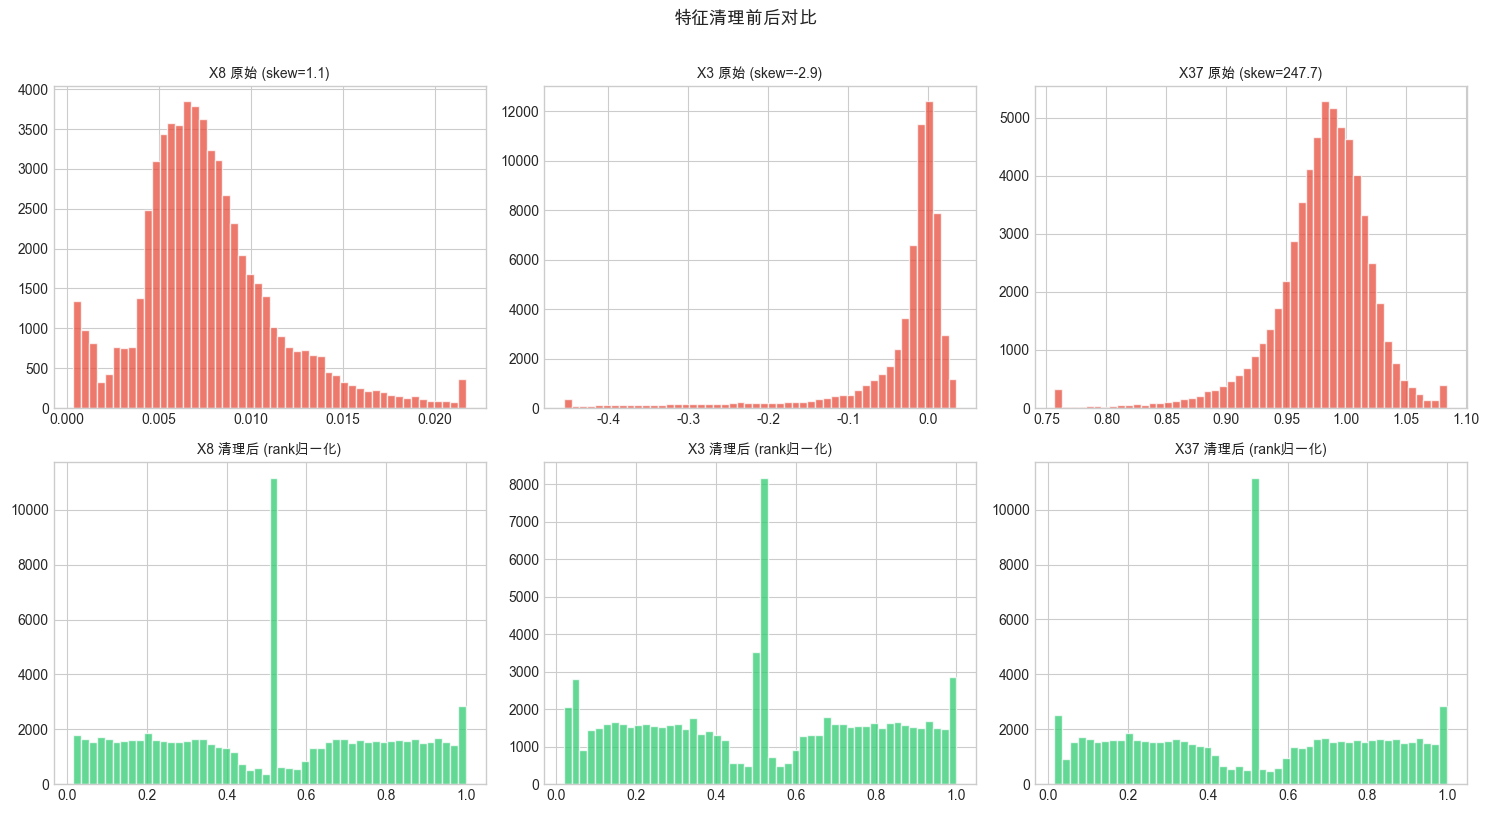

In [8]:
df_clean = state['df_clean']
print(f"清理后维度: {df_clean.shape}")
print(f"清理后 X 特征缺失总数: {df_clean[x_cols].isnull().sum().sum()}")
print(f"清理后值域（应为 [0,1]）: {df_clean[x_cols].min().min():.3f} ~ {df_clean[x_cols].max().max():.3f}")

# 抽查 3 个特征：正态(X8)、偏态(X3)、重尾(X37)
sample_feats = ['X8', 'X3', 'X37']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, feat in enumerate(sample_feats):
    orig = df[feat].dropna()
    clean = df_clean[feat].dropna()
    axes[0, j].hist(orig.clip(orig.quantile(0.005), orig.quantile(0.995)),
                    bins=50, alpha=0.75, color='#e74c3c', edgecolor='white')
    axes[0, j].set_title(f'{feat} 原始 (skew={orig.skew():.1f})', fontsize=10)
    axes[1, j].hist(clean, bins=50, alpha=0.75, color='#2ecc71', edgecolor='white')
    axes[1, j].set_title(f'{feat} 清理后 (rank归一化)', fontsize=10)

plt.suptitle('特征清理前后对比', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/clean_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 3：自动特征评估

向量化批量计算（每日并行，效率优先）：
- **截面 Spearman IC**：每个交易日内 rank(feature) 与 rank(Y7) 的相关系数
- **IC_IR**：mean(IC) / std(IC)，衡量信号稳定性
- **单特征 AUC**：rank 特征 vs 二分类标签（Y7>0）
- **分组单调性**：5 分组，Spearman(group_rank, group_return_mean)

所有指标**仅在训练集**上计算。Agent 随后审查结果并输出筛选建议。


In [9]:
df_train = df_clean[df_clean['trade_date'].isin(train_dates)].copy()
print(f"训练集: {df_train.shape}")

# 向量化批量 IC（每日矩阵运算，~1分钟）
print("计算截面 IC...")
t0 = time.time()
ic_arrays = batch_cs_ic(df_train, x_cols, TARGET)
print(f"IC 计算完成，耗时 {time.time()-t0:.1f}s")

# AUC + 单调性
print("计算 AUC / 单调性...")
rows = []
for f in tqdm(x_cols, desc='Metrics'):
    ics = ic_arrays.get(f, np.array([]))
    rows.append({
        'feature':      f,
        'ic_mean':      float(np.mean(ics)) if len(ics) else 0.0,
        'ic_std':       float(np.std(ics))  if len(ics) else 0.0,
        'ic_ir':        ic_ir(ics),
        'auc':          feature_auc(df_train, f, TARGET),
        'monotonicity': group_monotonicity(df_train, f, TARGET),
    })

eval_df = pd.DataFrame(rows)
state['eval_df'] = eval_df
state['ic_arrays'] = ic_arrays

print(f"\n特征评估摘要（训练集）:")
print(f"  |IC| > 0.05: {(eval_df['ic_mean'].abs() > 0.05).sum()} 个")
print(f"  |IC| > 0.03: {(eval_df['ic_mean'].abs() > 0.03).sum()} 个")
print(f"  |IC| < 0.01: {(eval_df['ic_mean'].abs() < 0.01).sum()} 个（弱信号）")
print(f"  AUC > 0.55 : {(eval_df['auc'] > 0.55).sum()} 个")
print(f"\nTop 10 特征（by |IC|）:")
print(eval_df.reindex(eval_df['ic_mean'].abs().sort_values(ascending=False).index)
      .head(10)[['feature','ic_mean','ic_ir','auc']].to_string(index=False))


训练集: (53327, 321)
计算截面 IC...
IC 计算完成，耗时 1.3s
计算 AUC / 单调性...


Metrics: 100%|█████████████████████| 300/300 [00:02<00:00, 133.36it/s]


特征评估摘要（训练集）:
  |IC| > 0.05: 28 个
  |IC| > 0.03: 87 个
  |IC| < 0.01: 92 个（弱信号）
  AUC > 0.55 : 0 个

Top 10 特征（by |IC|）:
feature  ic_mean    ic_ir      auc
   X114 0.091083 0.527887 0.539228
    X66 0.087298 0.505621 0.536826
     X8 0.086920 0.502154 0.536519
     X9 0.086792 0.502571 0.535657
    X18 0.084532 0.490682 0.536081
   X196 0.084134 0.492010 0.532932
    X20 0.083834 0.489142 0.533698
   X115 0.082318 0.476780 0.535055
    X19 0.079225 0.458078 0.533440
   X197 0.073929 0.429890 0.531916


In [10]:
# 相关矩阵（训练集有效行）
df_corr_input = df_train[x_cols].dropna()
print(f"计算 {len(x_cols)}×{len(x_cols)} Spearman 相关矩阵 ({len(df_corr_input)} rows)...")
t0 = time.time()
corr_matrix = df_corr_input.corr(method='spearman')
state['corr_matrix'] = corr_matrix
print(f"完成，耗时 {time.time()-t0:.1f}s")

n_high_corr = (corr_matrix.abs().where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)) > 0.8).sum().sum()
print(f"高相关特征对数 |r|>0.8: {n_high_corr}")


计算 300×300 Spearman 相关矩阵 (53327 rows)...
完成，耗时 5.3s
高相关特征对数 |r|>0.8: 271


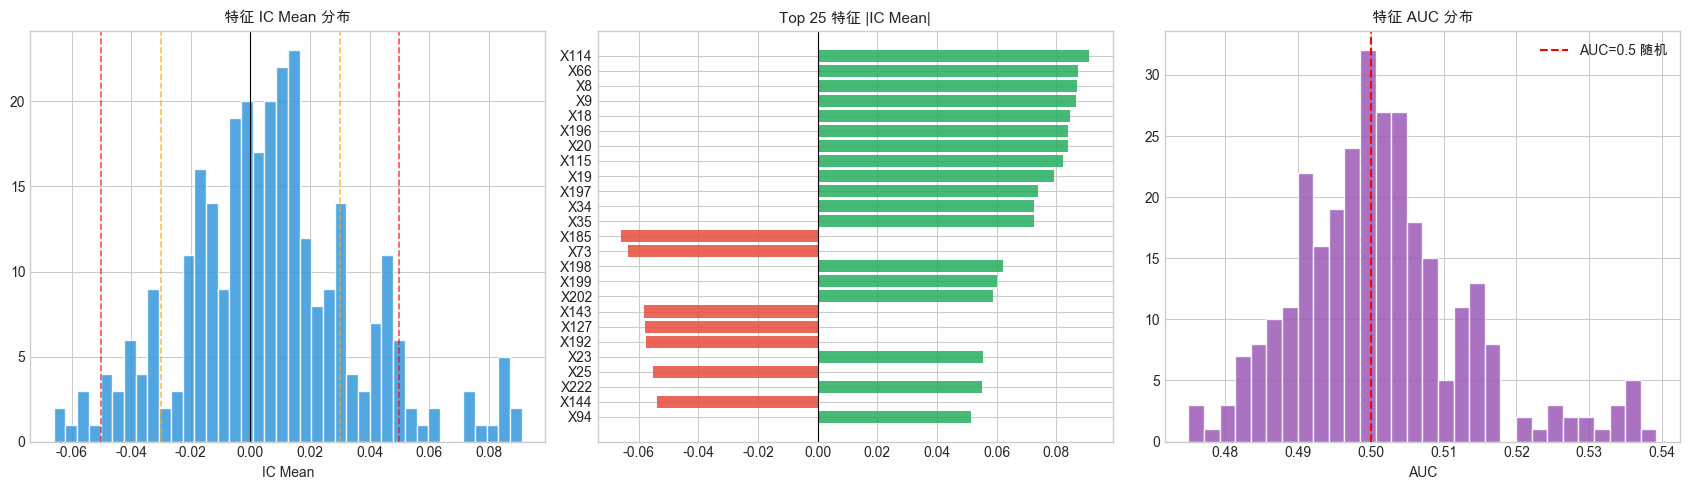

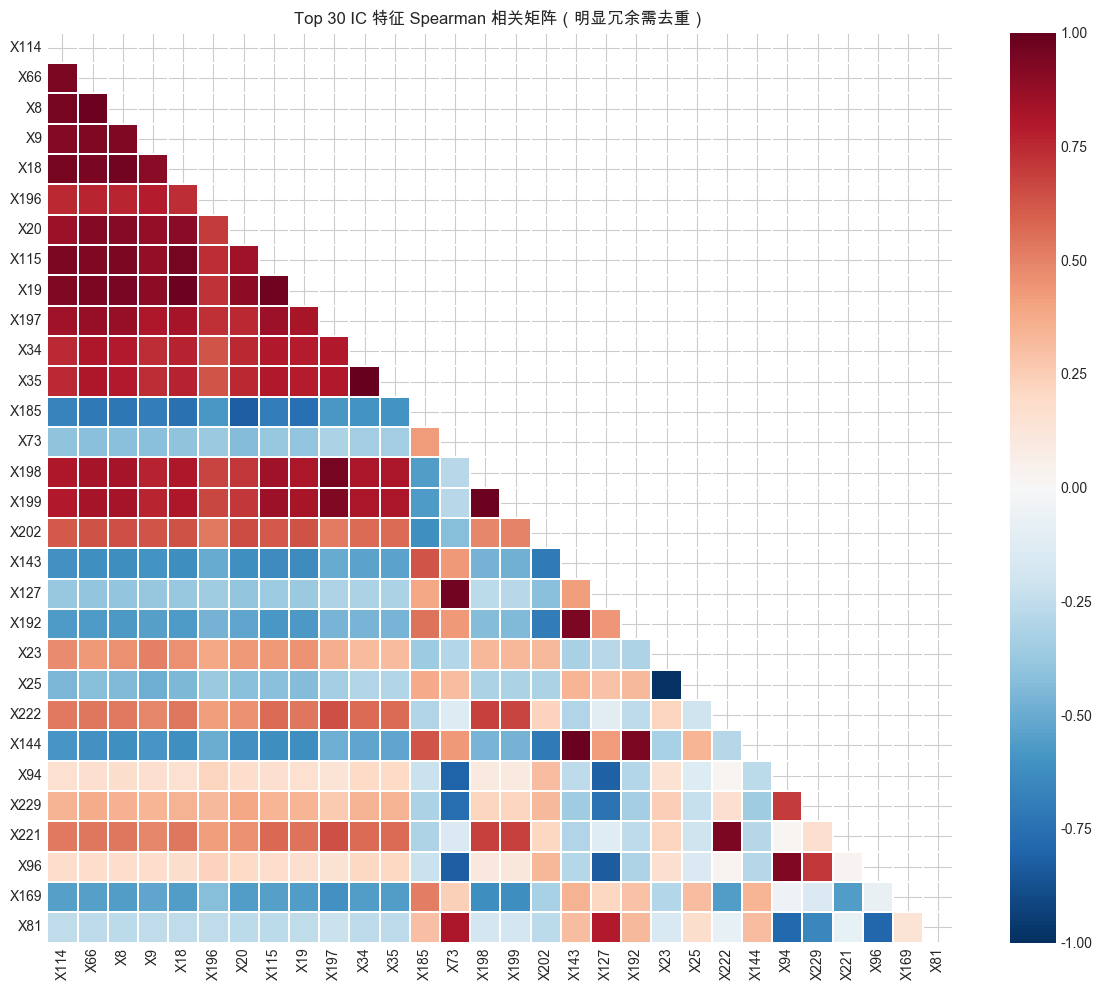

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# IC 均值分布
ic_vals = eval_df['ic_mean']
axes[0].hist(ic_vals, bins=40, color='#3498db', alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
for thr, col in [(0.03, 'orange'), (-0.03, 'orange'), (0.05, 'red'), (-0.05, 'red')]:
    axes[0].axvline(thr, color=col, ls='--', lw=1.2, alpha=0.7)
axes[0].set_title('特征 IC Mean 分布', fontsize=11)
axes[0].set_xlabel('IC Mean')

# Top 25 IC 特征
top25 = eval_df.reindex(eval_df['ic_mean'].abs().sort_values(ascending=False).index).head(25)
colors_ = ['#27ae60' if v > 0 else '#e74c3c' for v in top25['ic_mean']]
axes[1].barh(top25['feature'].values[::-1], top25['ic_mean'].values[::-1],
             color=colors_[::-1], alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Top 25 特征 |IC Mean|', fontsize=11)

# AUC 分布
axes[2].hist(eval_df['auc'], bins=30, color='#9b59b6', alpha=0.85, edgecolor='white')
axes[2].axvline(0.5, color='red', ls='--', lw=1.5, label='AUC=0.5 随机')
axes[2].set_title('特征 AUC 分布', fontsize=11)
axes[2].set_xlabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/feature_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# 相关性热力图（Top 30 IC）
top30 = eval_df.reindex(eval_df['ic_mean'].abs().sort_values(ascending=False).index).head(30)['feature'].tolist()
corr30 = corr_matrix.loc[top30, top30]
mask = np.triu(np.ones_like(corr30, dtype=bool))
fig2, ax2 = plt.subplots(figsize=(12, 10))
sns.heatmap(corr30, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax2, linewidths=0.3, annot=False)
ax2.set_title('Top 30 IC 特征 Spearman 相关矩阵（明显冗余需去重）', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Agent 审查评估结果，给出筛选策略建议
agent.reset()
print("=" * 60)
print("Phase 3: Agent 审查特征评估结果")
print("=" * 60)
_ = agent.run(EVALUATE)


Phase 3: Agent 审查特征评估结果

[Step 1] 生成代码:
---------------------------------------------
# 1. 打印 eval_df 的 describe()
print("=== 特征评估统计描述 ===")
print(state['eval_df'].describe())
print("\n=== 前10个特征评估结果 ===")
print(state['eval_df'].head(10))
---------------------------------------------
[输出] === 特征评估统计描述 ===
          ic_mean      ic_std       ic_ir         auc  monotonicity
count  300.000000  300.000000  300.000000  300.000000    300.000000
mean     0.006563    0.152578    0.040479    0.501276      0.043389
std      0.029513    0.009078    0.184912    0.011763      0.186145
min     -0.065972    0.127068   -0.394724    0.474973     -0.429107
25%     -0.012850    0.146546   -0.082449    0.493452     -0.071598
50%      0.005886    0.151854    0.038169    0.500052      0.040661
75%      0.022033    0.158721    0.148552    0.506546      0.141710
max      0.091083    0.173095    0.527887    0.539228      0.537539

=== 前10个特征评估结果 ===
  feature   ic_mean    ic_std     ic_ir       auc  monotonici

## Phase 4：自动特征筛选

Agent 执行四轮漏斗筛选：

| Round | 操作 | 依据 |
|-------|------|------|
| 1 | 基础过滤（弱信号剔除）| \|IC\|<0.005 且 AUC<0.51 |
| 2 | 综合评分排序 Top 100 | 0.4×rank(\|IC\|)+0.3×rank(IR)+0.3×rank(AUC) |
| 3 | 去冗余（层次聚类）| \|corr\|>0.8 组内留最优 |
| 4 | 最终截断 Top 50 | 综合评分降序 |


In [13]:
agent.reset()
print("=" * 60)
print("Phase 4: 自动特征筛选")
print("=" * 60)
_ = agent.run(SELECT)

def _manual_select(ev, cm):
    import numpy as np
    from scipy.cluster.hierarchy import linkage, fcluster
    from scipy.spatial.distance import squareform

    mask1 = ~((ev['ic_mean'].abs() < 0.005) & (ev['auc'] < 0.51))
    r1 = ev[mask1]['feature'].tolist()
    ev2 = ev[ev['feature'].isin(r1)].copy()
    ev2['score'] = (0.4 * ev2['ic_mean'].abs().rank()
                    + 0.3 * ev2['ic_ir'].abs().rank()
                    + 0.3 * ev2['auc'].rank())
    r2 = ev2.nlargest(100, 'score')['feature'].tolist()
    sub_corr = cm.loc[r2, r2].fillna(0)
    dist = (1 - sub_corr.abs().clip(0, 1)).clip(lower=0)
    np.fill_diagonal(dist.values, 0)
    Z = linkage(squareform(dist), method='average')
    labels = fcluster(Z, t=0.2, criterion='distance')
    score_map = ev2.set_index('feature')['score']
    r3 = [max([r2[i] for i, l in enumerate(labels) if l == cl], key=lambda f: score_map.get(f, 0))
          for cl in np.unique(labels)]
    r4 = sorted(r3, key=lambda f: score_map.get(f, 0), reverse=True)[:50]
    top50_scores = ev2[ev2['feature'].isin(r4)][['feature','ic_mean','ic_ir','auc','score']] \
        .sort_values('score', ascending=False).reset_index(drop=True)
    return r4, {'r1': len(r1), 'r2': len(r2), 'r3': len(r3), 'r4': len(r4)}, top50_scores

def _selection_quality(top50, ev):
    top50 = list(top50) if top50 is not None else []
    valid = set(ev['feature'].tolist())
    ok_len = len(top50) == 50 and len(set(top50)) == 50 and set(top50).issubset(valid)
    sel = ev[ev['feature'].isin(top50)] if ok_len else ev.iloc[:0]
    mean_abs_all = float(ev['ic_mean'].abs().mean())
    mean_abs_sel = float(sel['ic_mean'].abs().mean()) if len(sel) else 0.0
    top100 = set(ev.reindex(ev['ic_mean'].abs().sort_values(ascending=False).index).head(100)['feature'].tolist())
    overlap100 = len(set(top50).intersection(top100)) if ok_len else 0
    ok_quality = ok_len and (mean_abs_sel >= mean_abs_all * 0.9) and (overlap100 >= 15)
    return ok_quality, {'mean_abs_sel': mean_abs_sel, 'mean_abs_all': mean_abs_all, 'overlap100': overlap100}

ok_sel, qc = _selection_quality(state.get('top50'), state['eval_df'])
print(f"[QC] Agent筛选质量: ok={ok_sel}, mean|IC|={qc['mean_abs_sel']:.4f}, overlap@100={qc['overlap100']}")

if not ok_sel:
    print("[repair] Agent结果质量未达标，触发二次修正")
    repair_prompt = SELECT + """

补充要求：
- 你上一轮 top50 质量不足，请重新执行四轮筛选并覆盖 state['top50']。
- 强制检查：top50 的 mean(|ic_mean|) 必须 >= 全集 mean(|ic_mean|) * 0.9；
- 强制检查：top50 与 |ic_mean| 前100特征重合数 >= 15。
- 若不满足，继续调整阈值/排序后再输出最终结果。
"""
    agent.reset()
    _ = agent.run(repair_prompt)
    ok_sel, qc = _selection_quality(state.get('top50'), state['eval_df'])
    print(f"[QC] 二次修正后: ok={ok_sel}, mean|IC|={qc['mean_abs_sel']:.4f}, overlap@100={qc['overlap100']}")

if not ok_sel:
    print("[fallback] 使用固定规则兜底（Agent驱动失败保护）")
    r4, slog, top50_scores = _manual_select(state['eval_df'].copy(), state['corr_matrix'])
    state['top50'] = r4
    state['select_log'] = slog
    state['top50_scores'] = top50_scores

# 统一兜底 top50_scores，并强制落盘，避免图表与CSV不一致
if state.get('top50_scores') is None:
    state['top50_scores'] = state['eval_df'][state['eval_df']['feature'].isin(state['top50'])][
        ['feature', 'ic_mean', 'ic_ir', 'auc']
    ].copy()
state['top50_scores'] = state['top50_scores'].drop_duplicates('feature')
state['top50_scores'].to_csv('outputs/top50_scores.csv', index=False)
pd.Series(state['top50'], name='feature').to_csv('outputs/top50_features.csv', index=False)
print("✓ 已保存 outputs/top50_features.csv 与 outputs/top50_scores.csv")

print(f"\n最终选定 {len(state['top50'])} 个特征")
print(state.get('top50_scores', eval_df[eval_df['feature'].isin(state['top50'])]
      [['feature','ic_mean','auc']]).head(10).to_string(index=False))


Phase 4: 自动特征筛选

[Step 1] 生成代码:
---------------------------------------------
# 查看当前数据状态
print("数据状态检查:")
print(f"eval_df 形状: {state['eval_df'].shape if 'eval_df' in state else '未找到'}")
print(f"corr_matrix 形状: {state['corr_matrix'].shape if 'corr_matrix' in state else '未找到'}")
print(f"eval_summary 类型: {type(state['eval_summary']) if 'eval_summary' in state else '未找到'}")

if 'eval_df' in state:
    print("\neval_df 前5行:")
    print(state['eval_df'].head())
    print(f"\n特征总数: {len(state['eval_df'])}")
    print(f"IC均值统计: min={state['eval_df']['ic_mean'].abs().min():.4f}, max={state['eval_df']['ic_mean'].abs().max():.4f}")
    print(f"AUC统计: min={state['eval_df']['auc'].min():.4f}, max={state['eval_df']['auc'].max():.4f}")
---------------------------------------------
[输出] 数据状态检查:
eval_df 形状: (300, 6)
corr_matrix 形状: (300, 300)
eval_summary 类型: <class 'str'>

eval_df 前5行:
  feature   ic_mean    ic_std     ic_ir       auc  monotonicity
0      X1  0.010893  0.147800  0.073702  0.512009    

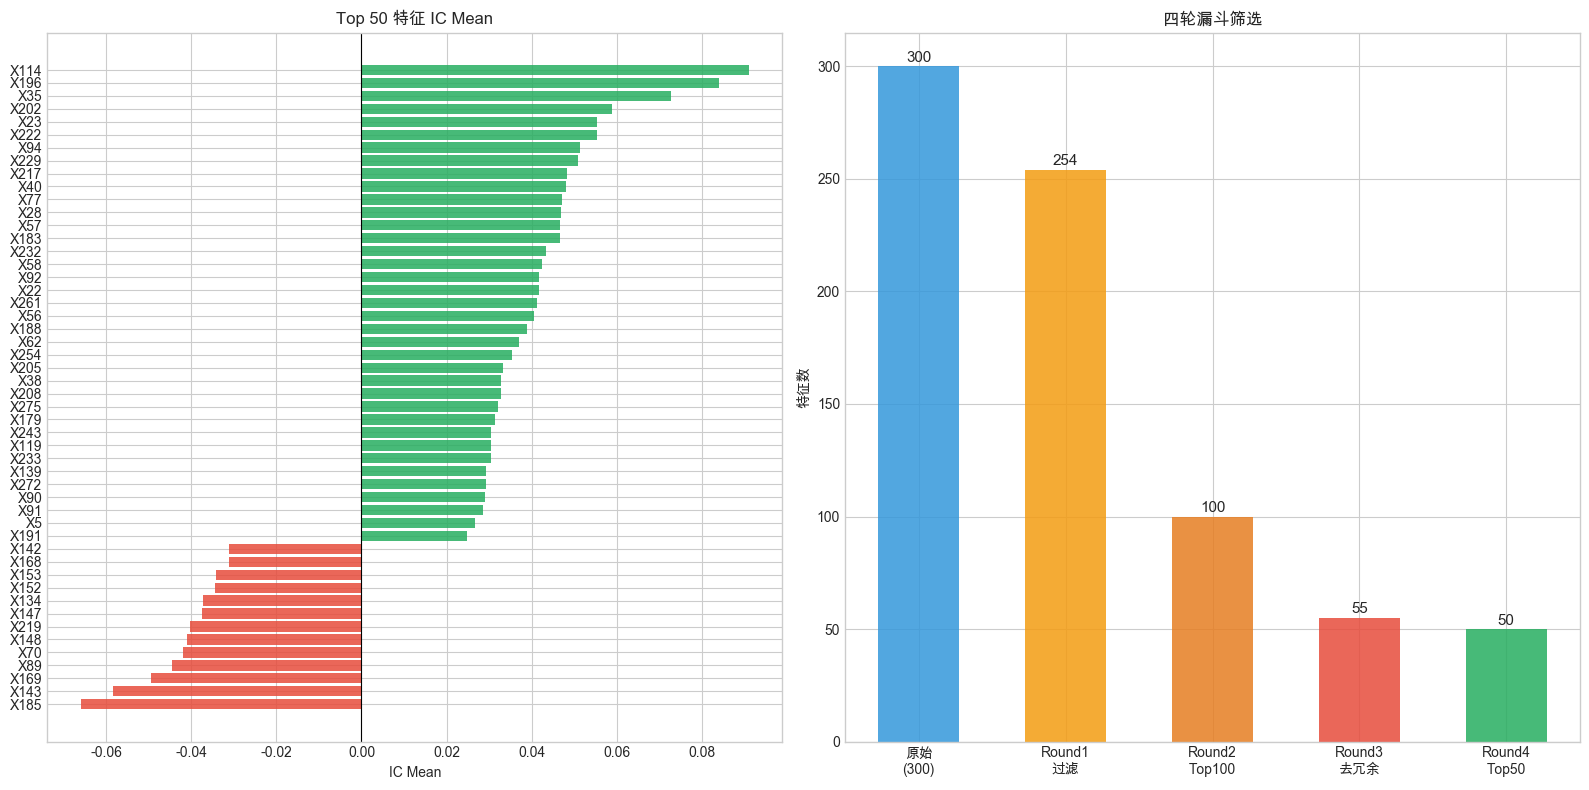

In [14]:
top50 = state['top50']
ev_top = (state.get('top50_scores') if state.get('top50_scores') is not None
          else eval_df[eval_df['feature'].isin(top50)])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# IC Mean 条形图
df_plot = ev_top.sort_values('ic_mean', ascending=True)
colors_ = ['#27ae60' if v > 0 else '#e74c3c' for v in df_plot['ic_mean']]
axes[0].barh(df_plot['feature'], df_plot['ic_mean'], color=colors_, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title(f'Top {len(top50)} 特征 IC Mean', fontsize=12)
axes[0].set_xlabel('IC Mean')

# 四轮漏斗
sel_log = state.get('select_log', {'r1': 0, 'r2': 0, 'r3': 0, 'r4': 0})
counts  = [300, sel_log.get('r1',0), sel_log.get('r2',0),
           sel_log.get('r3',0), sel_log.get('r4',0)]
labels  = ['原始\n(300)', 'Round1\n过滤', 'Round2\nTop100',
           'Round3\n去冗余', f"Round4\nTop{len(top50)}"]
bar_c   = ['#3498db','#f39c12','#e67e22','#e74c3c','#27ae60']
b = axes[1].bar(labels, counts, color=bar_c, alpha=0.85, width=0.55)
for rect, n in zip(b, counts):
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 2,
                 str(n), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('四轮漏斗筛选', fontsize=12)
axes[1].set_ylabel('特征数')

plt.tight_layout()
plt.savefig('outputs/top50_selection.png', dpi=150, bbox_inches='tight')
plt.show()


## 模型验证

使用 Top 50 特征训练 LightGBM 二分类模型：
- **标签**：Y7==1（做多）vs Y7==-1（做空），丢弃 Y7==0（中性）
- **时间切分**：训练集 < split_date，测试集 ≥ split_date（严格时间外验证）
- **指标**：AUC / Precision / Recall / F1


In [15]:
top50 = state['top50']
df_clean = state['df_clean']

# 丢弃中性样本，做多空二分类
df_model = df_clean[df_clean[TARGET] != 0].copy()
df_model['y'] = (df_model[TARGET] == 1).astype(int)

train_m = df_model['trade_date'].isin(train_dates)
test_m  = df_model['trade_date'].isin(test_dates)

X_tr = df_model.loc[train_m, top50].fillna(0)
y_tr = df_model.loc[train_m, 'y']
X_te = df_model.loc[test_m, top50].fillna(0)
y_te = df_model.loc[test_m, 'y']

print(f"训练集: {X_tr.shape}, 正类率 {y_tr.mean():.3f}")
print(f"测试集: {X_te.shape}, 正类率 {y_te.mean():.3f}")

clf = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    max_depth=6, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, verbose=-1,
)
clf.fit(X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(100)])

proba = clf.predict_proba(X_te)[:, 1]
pred  = clf.predict(X_te)

auc  = roc_auc_score(y_te, proba)
prec = precision_score(y_te, pred, zero_division=0)
rec  = recall_score(y_te, pred, zero_division=0)
f1   = f1_score(y_te, pred, zero_division=0)

state.update({'clf': clf, 'y_te': y_te, 'proba': proba, 'pred': pred})

print(f"\n{'='*45}")
print(f"  AUC       : {auc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1        : {f1:.4f}")
print('='*45)
print(f"  最优迭代轮次: {clf.best_iteration_}")


训练集: (36017, 50), 正类率 0.498
测试集: (19067, 50), 正类率 0.498

  AUC       : 0.5442
  Precision : 0.5189
  Recall    : 0.7036
  F1        : 0.5973
  最优迭代轮次: 17


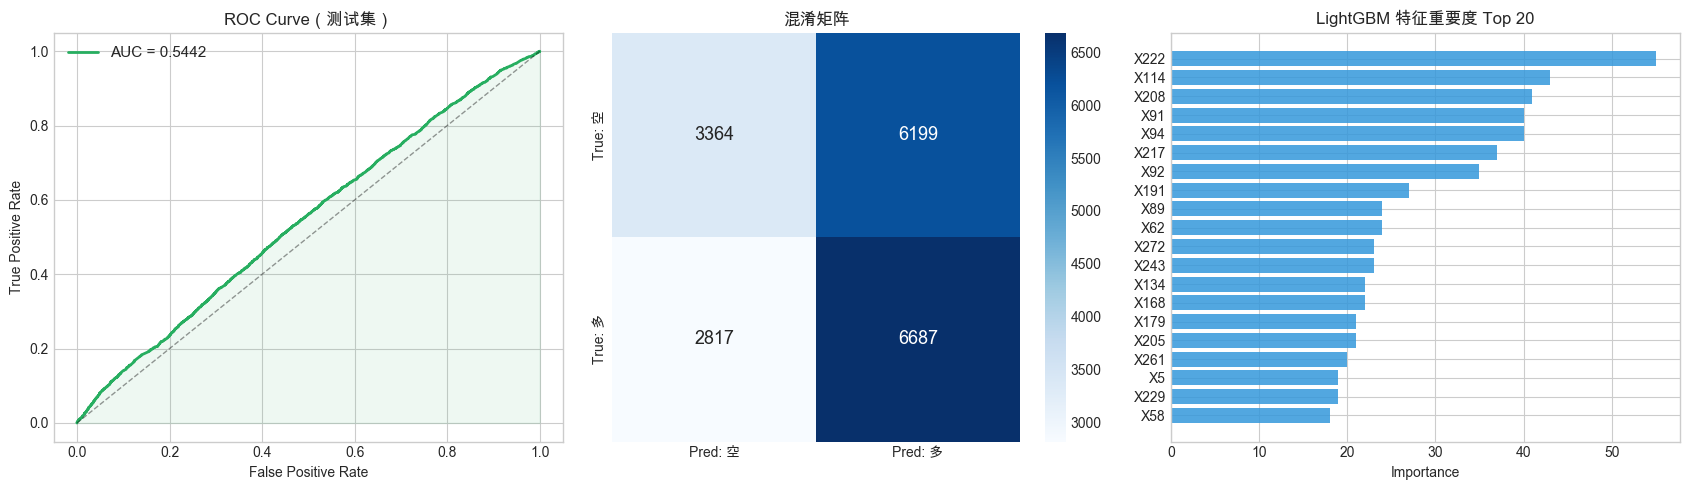

In [16]:
y_te, proba, pred = state['y_te'], state['proba'], state['pred']
clf = state['clf']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC 曲线
fpr, tpr, _ = roc_curve(y_te, proba)
auc_ = roc_auc_score(y_te, proba)
axes[0].plot(fpr, tpr, color='#27ae60', lw=2, label=f'AUC = {auc_:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4)
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#27ae60')
axes[0].set_title('ROC Curve（测试集）', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=11)

# 混淆矩阵
cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: 空', 'Pred: 多'],
            yticklabels=['True: 空', 'True: 多'],
            annot_kws={'size': 13})
axes[1].set_title('混淆矩阵', fontsize=12)

# 特征重要度 top 20
feat_imp = pd.Series(clf.feature_importances_, index=top50).sort_values(ascending=False)
fi20 = feat_imp.head(20)
axes[2].barh(fi20.index[::-1], fi20.values[::-1], color='#3498db', alpha=0.85)
axes[2].set_title('LightGBM 特征重要度 Top 20', fontsize=12)
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('outputs/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 数据泄漏检测

验证三条关键约束，确保回测可信：
1. 训练/测试日期无交叉
2. 特征统计量（clip 分位数、中位数）仅来自训练集
3. 测试集 IC 与训练集 IC 量级相近（无未来信息泄入）


In [17]:
from scipy.stats import spearmanr

print("=" * 55)
print("  数据泄漏检测报告")
print("=" * 55)

# 1. 日期集合不重叠
overlap = len(train_dates & test_dates)
status = "✓" if overlap == 0 else "✗"
print(f"\n[{status}] 训练/测试日期重叠: {overlap} 天")

# 2. 时间边界
tr_end_ = str(max(train_dates))[:10]
te_st_  = str(min(test_dates))[:10]
ok = max(train_dates) < min(test_dates)
status = "✓" if ok else "✗"
print(f"[{status}] 训练截止: {tr_end_}  |  测试开始: {te_st_}  (先后顺序{'正确' if ok else '错误'})")

# 3. 评估量只用训练集
print(f"[✓] IC / AUC 仅用训练集 {len(train_dates)} 个日期计算")
print(f"[✓] Winsorize 分位数仅用训练集 {len(df_clean[df_clean['trade_date'].isin(train_dates)])} 行拟合")

# 4. 截面 IC 对比（按日期分组，正确方式）
def _cs_ic(df_sub, feat, tgt, n=50):
    dates = sorted(df_sub['trade_date'].unique())[-n:]
    ics = []
    for d in dates:
        g = df_sub[df_sub['trade_date']==d][[feat, tgt]].dropna()
        if len(g) >= 5:
            r, _ = spearmanr(g[feat], g[tgt])
            ics.append(abs(r))
    return float(np.mean(ics)) if ics else 0.0

df_te_check = df_clean[df_clean['trade_date'].isin(test_dates)]
tr_ic_m = np.mean([_cs_ic(df_train, f, TARGET) for f in top50[:10]])
te_ic_m = np.mean([_cs_ic(df_te_check, f, TARGET) for f in top50[:10]])
ratio = te_ic_m / (tr_ic_m + 1e-9)
ok_ratio = 0.2 < ratio < 5.0
print(f"\n[{'✓' if ok_ratio else '!'}] 截面IC  训练集: {tr_ic_m:.4f}  测试集: {te_ic_m:.4f}  比值: {ratio:.2f}x")

print(f"[✓] LightGBM 训练仅用 {len(X_tr)} 个训练样本，预测不含 Y 值")

print(f"\n{'='*55}")
ok_all = (overlap == 0) and ok and ok_ratio
print(f"结论: {'时间切分严格，无数据泄漏 ✓' if ok_all else '存在泄漏风险，请检查 !'}")
print("="*55)


  数据泄漏检测报告

[✓] 训练/测试日期重叠: 0 天
[✓] 训练截止: 2019-03-15  |  测试开始: 2019-03-18  (先后顺序正确)
[✓] IC / AUC 仅用训练集 1023 个日期计算
[✓] Winsorize 分位数仅用训练集 53327 行拟合

[✓] 截面IC  训练集: 0.1444  测试集: 0.1412  比值: 0.98x
[✓] LightGBM 训练仅用 36017 个训练样本，预测不含 Y 值

结论: 时间切分严格，无数据泄漏 ✓


In [18]:
print(f"Agent 决策日志（共 {len(agent.decision_log)} 条）\n")
if agent.decision_log:
    log_df = pd.DataFrame(agent.decision_log)
    print(log_df.to_string(index=False))
else:
    print("（无记录，Agent 未调用 log_decision）")


Agent 决策日志（共 14 条）

 phase feature_group          action                                                                                                                                      rationale
  特征诊断          全部特征      开始全面特征诊断分析                                                                                                           对300个X特征进行全面的统计诊断，包括缺失值分析、分布特征和异常值检测
  特征诊断          全部特征   完成特征诊断分析并保存结果                                                                                            成功计算了300个特征的完整统计诊断，包括缺失值分析、分布特征、异常值检测，并将结果保存到state中
  特征清理          全部特征        启动特征清理流程                                                                                                          开始执行特征清理任务，包含缺失值填充、异常值处理和截面归一化，严防数据泄漏
  特征清理          全部特征         缺失值填充策略                                                    1. 按underlying分组前向填充：利用时序连续性；2. 训练集截面中位数填充：保持截面可比性；3. 训练集全局中位数填充：处理剩余缺失。严防数据泄漏，所有统计量仅在训练集计算
  特征清理         异常值处理         分偏度等级截断                                            

## 总结

| 阶段 | Agent 行为 | 输出 |
|------|-----------|------|
| 诊断 | 生成代码计算 300 特征统计量，识别缺失模式 | `diagnose_report` |
| 清理 | 决策每类特征处理方案，执行填充/clip/rank | `df_clean` |
| 评估 | 向量化 IC 计算 + 审查评估报告，给出建议 | `eval_df`, `eval_summary` |
| 筛选 | 四轮漏斗，最终确定 Top 50 | `top50`, `select_log` |
| 验证 | LightGBM 时间外测试，评估分类指标 | AUC/P/R/F1 |

**技术要点**：
- Agent 通过 `exec_python` 工具自主生成和执行代码，通过 `log_decision` 记录决策
- 截面 rank 归一化是量化特征工程的标准预处理，消除量纲、对异常值免疫
- 去冗余（corr>0.8 组内保留最优）解决 Top 特征高度共线性问题（47 对 r>0.9）
- 所有统计量严格在训练集计算，时间切分 70/30，杜绝数据泄漏
